# Does Weath Make Health? A Brief Look At Simple Linear Regressions on Life Expectancy, Wealth, and Wealth Inequality

Life expectancy is a widely used indicator of the health of a population. When comparing modern medicine, technology, etc. to their past counterparts, it is typical to cite increased life expectancy to demonstrate improvement.

This project will seek to explore the following questions: 

   1. Which is more strongly associated with a nation's life expectancy, the nation's overall wealth, or its wealth inequality?
   2. How do these associations change when we look at wealthier countries?

For wealth, we will use the measure of GDP per capita. Once we have looked at the associations found with GDP per capita and life expectancy, we will look at associations between wealth inequality and life expectancy by using data on a well-known measure of wealth inequality - the Gini coefficient: https://en.wikipedia.org/wiki/Gini_coefficient. 

The datasets this project will analyze are from Our World In Data (OWID): https://ourworldindata.org/.

As an added note, the analysis will only look at data from the 21st century before the COVID-19 pandemic, i.e., between 2000-2019. This way, the data will be giving us a sense of how things stand in the "modern" world, while also avoiding complications from the pandemic.

In [3]:
# RUN ME!
# Global Imports
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

In [4]:
# RUN ME!
# Loads Datasets from Our World in Data
life_expectancy_df = pd.read_csv("https://ourworldindata.org/grapher/life-expectancy.csv?v=1&csvType=full&useColumnShortNames=false", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
gdp_df = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=false", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
gini_df = pd.read_csv("https://ourworldindata.org/explorers/inequality.csv?v=1&csvType=full&useColumnShortNames=false&Data=World+Inequality+Database+%28Incomes+before+tax%29&Indicator=Gini+coefficient", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'}) 

## Analyzing GDP Per Capita

We will begin by analyzing how GDP per capita is associated with life expectancy. This will involve selecting the previously discussed modern, pre-COVID timespan, then calculating the mean GDP per capita across those years for each unique entity in the OWID dataset. In this process, we will build functions that we will later use for our analysis of Gini coefficient data.

### Specifying The Modern, Pre-COVID Timespan

As noted earlier: this project will be focusing on data recorded between 2000 and 2019. To select this data, we will use the function defined in the code cell below.

In [5]:
# RUN ME!

"""
This cell defines the function 'timespan'

The function takes in 3 inputs:
    - A pandas DataFrame
    - An integer 'start_year'
    - An integer 'end_year'
    
The function then returns a pandas DataFrame which only includes rows
where the entry in the 'Years' column is within the time span defined 
by the 'start_year' and 'end_year' inputs.
"""

def timespan(df: pd.DataFrame, start_year: int, end_year: int):
    
    assert start_year < end_year
    # Ensures a timespan that makes sense
    
    assert type(df) == pd.DataFrame
    assert type(start_year) == int
    assert type(end_year) == int
    # Ensures correct datatypes are being used for each input
    
    assert 'Year' in df.columns
    # Ensures that there is a column titled 'Year'
    
    return df.loc[(df['Year'] >= start_year) & (df['Year'] <= end_year)]


In [8]:
# RUN ME!

"""
This cell uses the 'timespan' function to get the desired
modern pre-COVID life expectancy and GDP data.
"""

start = 2000
end = 2019

MPC_LE = timespan(life_expectancy_df, start, end)
MPC_GDP = timespan(gdp_df, start, end)
display(MPC_LE)
display(MPC_GDP)

,Entity,Code,Year,Life expectancy
50,Afghanistan,AFG,2000,55.0047
51,Afghanistan,AFG,2001,55.5113
52,Afghanistan,AFG,2002,56.2251
53,Afghanistan,AFG,2003,57.1713
54,Afghanistan,AFG,2004,57.8098
...,...,...,...,...
21556,Zimbabwe,ZWE,2015,58.9895
21557,Zimbabwe,ZWE,2016,59.7601
21558,Zimbabwe,ZWE,2017,60.2626
21559,Zimbabwe,ZWE,2018,60.9055


,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia
...,...,...,...,...,...
7230,Zimbabwe,ZWE,2015,5102.7144,Africa
7231,Zimbabwe,ZWE,2016,5070.4023,Africa
7232,Zimbabwe,ZWE,2017,5234.3840,Africa
7233,Zimbabwe,ZWE,2018,5415.4697,Africa


In [9]:
"""
This cell defines the 'get_mean' function.

The function takes in 3 inputs:
    - A pandas DataFrame
    - A column or list of columns to group by
    - A column to use to calculate the mean among the groups
    
The function returns a dataframe with a mean calculated for the groups defined by grouping_cols
"""

def get_mean(df: pd.DataFrame, grouping_cols, mean_col: str):
    
    assert mean_col in df.columns
    
    return pd.DataFrame(df.groupby(grouping_cols)[mean_col].mean().reset_index())

In [10]:
mean_LE = get_mean(MPC_LE, ['Entity', 'Code'], 'Life expectancy')
mean_GDP = get_mean(MPC_GDP, ['Entity', 'Code'], 'GDP per capita')
# Calculates mean life expectancy and mean GDP per capita

print('mean_LE:')
display(mean_LE)
# Displays new life expectancy data

print('mean_GDP:')
display(mean_GDP)
# Displays new GDP per capita data

mean_LE:


,Entity,Code,Life expectancy
0,Afghanistan,AFG,59.913765
1,Africa,OWID_AFR,58.175875
2,Albania,ALB,77.500790
3,Algeria,DZA,73.727430
4,American Samoa,ASM,72.310680
...,...,...,...
241,Western Sahara,ESH,66.990430
242,World,OWID_WRL,69.728945
243,Yemen,YEM,66.084020
244,Zambia,ZMB,55.641590


mean_GDP:


,Entity,Code,GDP per capita
0,Afghanistan,AFG,2427.670195
1,Albania,ALB,11434.504675
2,Algeria,DZA,14103.516500
3,Andorra,AND,61412.622850
4,Angola,AGO,9850.186815
...,...,...,...
207,Vanuatu,VUT,3285.126315
208,Vietnam,VNM,7396.884890
209,World,OWID_WRL,15979.330175
210,Zambia,ZMB,3043.818755


### Merging and Cleaning Up the 'Entity' Column

If you ran the cells above, you might notice a couple of things:

   1. There are entries in the 'Entity' columns in both DataFrames which are regions (i.e., entries like 'World' and 'Africa'), rather than individual nations.
    
   2. There are 34 less entries in the mean_GDP dataframe than there are in the mean_LE dataframe. This is because there are many countries for which GDP data is not recorded.

Since this analysis is meant to provide us information about individual nations, it would be appropriate for us to remove any non-nation entries (as well as any NA values.) Thankfully, the OWID data makes this pretty straightforward, as non-nation entries consistently start with 'OWID_'

Additionally, since we will be narrowing our analysis to wealthy nations later on, it will make sense for us to merge these dataframes together.

We can do this with code cell below.

In [11]:
mean_LE = (mean_LE.loc[(~mean_LE['Code'].str.startswith('OWID_')) & mean_LE['Code'].notna()]).reset_index(drop = True)
mean_GDP = (mean_GDP.loc[(~mean_GDP['Code'].str.startswith('OWID_')) & (mean_GDP['Code'].notna())]).reset_index(drop = True)
# Cleans dataframes by removing NA values and values that start with 'OWID_'

print('Cleaned mean_LE:')
display(mean_LE)
# Displays cleaned LE data

print('Cleaned mean_GDP:')
display(mean_GDP)
# Displays cleaned GDP data

GDP_LE_DF = pd.merge(mean_LE, mean_GDP, on = ['Entity', 'Code'], how = 'inner')
# Merges dataframes

print('Merged DataFrame - GDP_LE_DF:')
display(GDP_LE_DF)
# Displays the merged dataframe

Cleaned mean_LE:


,Entity,Code,Life expectancy
0,Afghanistan,AFG,59.913765
1,Albania,ALB,77.500790
2,Algeria,DZA,73.727430
3,American Samoa,ASM,72.310680
4,Andorra,AND,83.674660
...,...,...,...
231,Wallis and Futuna,WLF,76.728260
232,Western Sahara,ESH,66.990430
233,Yemen,YEM,66.084020
234,Zambia,ZMB,55.641590


Cleaned mean_GDP:


,Entity,Code,GDP per capita
0,Afghanistan,AFG,2427.670195
1,Albania,ALB,11434.504675
2,Algeria,DZA,14103.516500
3,Andorra,AND,61412.622850
4,Angola,AGO,9850.186815
...,...,...,...
200,Uzbekistan,UZB,5741.560300
201,Vanuatu,VUT,3285.126315
202,Vietnam,VNM,7396.884890
203,Zambia,ZMB,3043.818755


Merged DataFrame - GDP_LE_DF:


,Entity,Code,Life expectancy,GDP per capita
0,Afghanistan,AFG,59.913765,2427.670195
1,Albania,ALB,77.500790,11434.504675
2,Algeria,DZA,73.727430,14103.516500
3,Andorra,AND,83.674660,61412.622850
4,Angola,AGO,55.917735,9850.186815
...,...,...,...,...
193,Uzbekistan,UZB,69.247850,5741.560300
194,Vanuatu,VUT,69.595875,3285.126315
195,Vietnam,VNM,73.554560,7396.884890
196,Zambia,ZMB,55.641590,3043.818755


### Visualizing GDP Per Capita vs. Life Expectancy

Now that we have a merged DataFrame with appropriate row entries, we can visualize the correlation between GDP Per Capita and Life Expectancy.

Running the cell below creates a scatterplot and a best fit line using some functions from NumPy and matplotlib.

In [12]:
"""
This cell defines the 'plot_df' function

The function takes in 3 inputs:
    - A pandas DataFrame
    - A string to specify the column data to use for the x_axis
    - A string to specify the column data to use for the y_axis
    
The function returns a display of a scatterplot using this data.
"""

def plot_df(df: pd.DataFrame, x_col: str, y_col: str):
    
    plt.scatter(df[x_col], df[y_col])
    # Creates scatterplot data using columns from the merged DataFrame
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(x_col + ' vs ' + y_col + ' (' + str(start) + '-' + str(end) + ')' )
    # Labels the axes and title of the chart according to input columns and the 'start' and 'end' years defined earlier.

    m, b = np.polyfit(df[x_col], df[y_col], 1)
    # Creates best fit line using NumPy's .polyfit function
    # It finds the slope: m, and the y-intercept: b

    plt.plot(df[x_col], m*df[x_col] + b)
    # Using the values found by the polyfit function, 

    return plt.show()
    # Displays the resulting plot


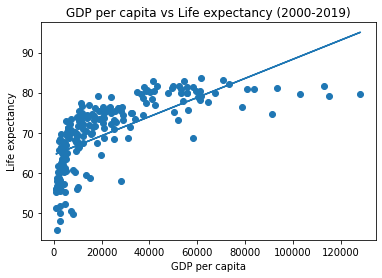

In [13]:
plot_df(GDP_LE_DF, 'GDP per capita', 'Life expectancy')

### Interpreting The Scatterplot

If we glance at the scatterplot above, we can see that the best fit line indicates a positive association between GDP per capita and life expectancy. If we look at the plot carefully, however, we might infer that this association isn't telling us the whole story. 

For one thing, it's pretty clear that a line is an awkward fit for this data. This is made especially obvious when we compare the data below and above the mark of 20,000 GDP per capita along the x-axis. There seems to be a sharp incline towards the lower part of the x-axis, after which the trend "levels out."

A natural follow-up question might be: if we only examine the countries above a certain GDP per capita, does the strength of this association change? To investigate that question, we can define a function that selects data from our merged dataset based on GDP per capita.

In [14]:
"""
This cell defines the 'GDP_above_n' function.
It takes in a pandas dataframe and an integer n as its inputs.
It returns a dataframe where the row entries satisfy the condition 
of having 'GDP per capita' values strictly greater than n.
"""

def GDP_above_n(df: pd.DataFrame, n: int):
    assert 'GDP per capita' in df.columns
    return df.loc[df['GDP per capita'] > n]

### Taking a Closer Look

Now that we have a function which selects data based on GDP per capita, we can narrow the data down and see more clearly if the association holds. The cell below will display scatterplots for GDP per capita thresholds above 20,000, 40,000, and 60,000.

Greater than 20,000:


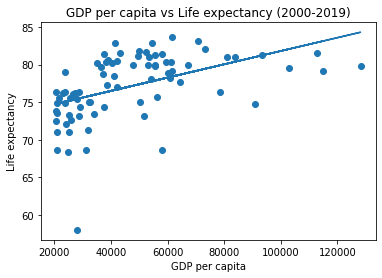

Greater than 40,000:


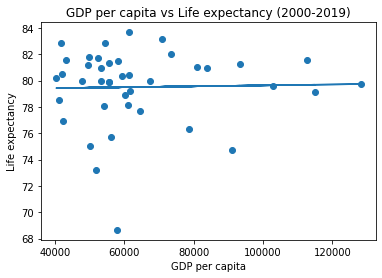

Greater than 60,000:


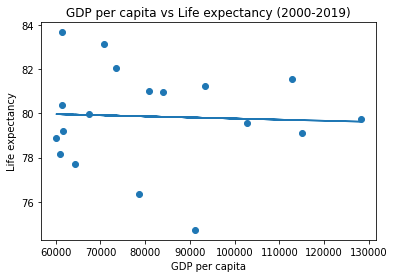

In [15]:
above_twenty_K = GDP_above_n(GDP_LE_DF, 20000)
# Gets GDP per capita values above 20,000

above_forty_K = GDP_above_n(GDP_LE_DF, 40000)
# Gets GDP per capita values above 40,000

above_sixty_K = GDP_above_n(GDP_LE_DF, 60000)
# Gets GDP per capita values above 60,000

print("Greater than 20,000:")
plot_df(above_twenty_K, 'GDP per capita', 'Life expectancy')
# Displays above_twenty_K

print("Greater than 40,000:")
plot_df(above_forty_K, 'GDP per capita', 'Life expectancy')
# Displays above_forty_K

print("Greater than 60,000:")
plot_df(above_sixty_K, 'GDP per capita', 'Life expectancy')
# Displays above_sixty_K

### Interpreting the New Scatterplots

We can see that the slope of the best fit line becomes much weaker as we remove countries at or below 20,000, and weaker still as we increment above that. Note that the slope actually becomes negative when we only examine countries above 60,000 GDP per capita.

## Comparing Gini Coefficient and GDP Per Capita Associations with Life Expectancy

Now that we have taken a look at the slopes of the best fit lines between GDP per capita and life expectancy, we can start doing the same sort of analysis with the Gini coefficient. Once we merge the previous data frame: GDP_LE_DF with properly tidied up Gini coefficient data, we can compare how life expectancy is associated with GDP per capita among the sample population of countries.

### Tidying Up The Data From The Gini Coefficient DataFrame

To tidy up gini_df, we can use some of the functions we built to clean up the GDP per capita data before. Beyond using these functions, we will also rename columns to make it possible to merge the resulting dataframe with GDP_LE_DF. 

This process is shown in the code cell below.

In [17]:
"""
This cell tidies up the previously loaded 'gini_df' dataframe, 
performs similar analysis to what we saw with the GDP per capita data,
then merges this with the 'GDP_LE_DF' made earlier 
"""

MPC_gini_df = timespan(gini_df, start, end)
# Specifies modern, pre-COVID timespan

mean_gini = get_mean(MPC_gini_df, 'Country','Gini coefficient (before tax) (World Inequality Database)')
# Gets mean of gini coefficient values recorded within 2000-2019 timespan for each country

mean_gini = mean_gini.rename(columns = {'Gini coefficient (before tax) (World Inequality Database)': 'Gini Coefficient', 'Country': 'Entity'})
# Renames columns to make dataframe mergible and more legible

MERGED_DF = pd.merge(GDP_LE_DF, mean_gini, on = ['Entity'], how = 'inner')

display(MERGED_DF)

,Entity,Code,Life expectancy,GDP per capita,Gini Coefficient
0,Afghanistan,AFG,59.913765,2427.670195,0.510867
1,Albania,ALB,77.500790,11434.504675,0.484367
2,Algeria,DZA,73.727430,14103.516500,0.555767
3,Angola,AGO,55.917735,9850.186815,0.659167
4,Argentina,ARG,75.519860,25722.573750,0.594100
...,...,...,...,...,...
141,Uruguay,URY,76.365145,23744.024500,0.578547
142,Uzbekistan,UZB,69.247850,5741.560300,0.569900
143,Vietnam,VNM,73.554560,7396.884890,0.576144
144,Zambia,ZMB,55.641590,3043.818755,0.687280


### Displaying the Merged Data

Now that we have cleaned and merged the Gini coefficient data, we can display its relationship with life expectancy, and compare this relationship with GDP per capita. Additionally, like before, we can use the GDP_above_n function to compare the relationships between these variables after omitting nations with specified GDP per capita levels.

Note: There is not a perfect overlap between countries for which OWID has GDP per capita data and the countries for which OWID has Gini coefficient data, the merging of gini_df and GDP_LE_DF omits quite a few entries and changes the appearance of the GDP per capita vs life expectancy scatterplot.

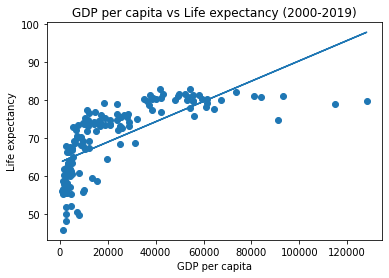

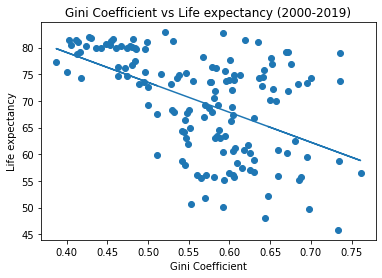

In [18]:
"""
This cell uses our previously-defined 'plot_df' function to display the relationships between
life expectancy and GDP per capita and the Gini coefficient.
"""

plot_df(MERGED_DF, 'GDP per capita', 'Life expectancy')
plot_df(MERGED_DF, 'Gini Coefficient', 'Life expectancy')

Greater than 20,000:


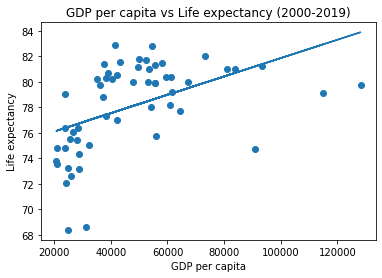

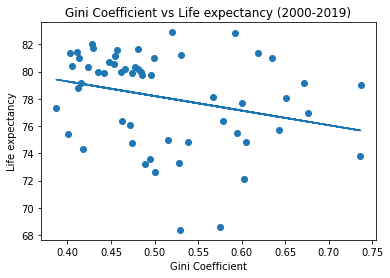

Greater than 40,000:


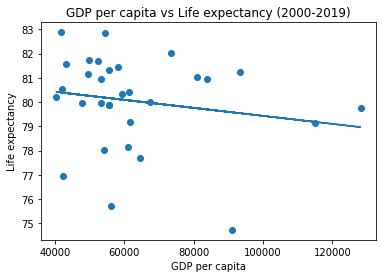

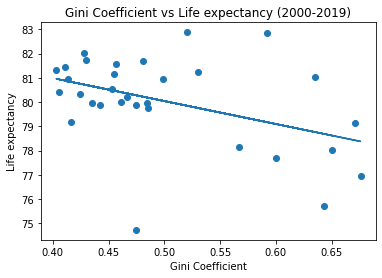

Greater than 60,000:


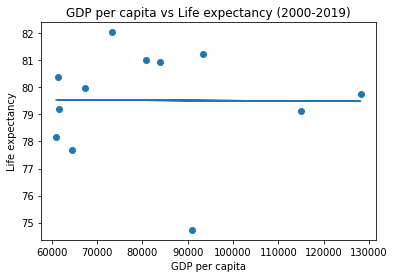

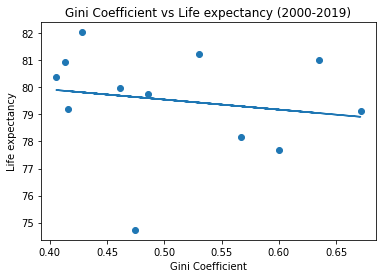

In [19]:
"""
This cell uses the 'GDP_above_n' function to specify data based on GDP
then displays the selected data
"""

merged_twenty_K = GDP_above_n(MERGED_DF, 20000)
# Gets GDP per capita values above 20,000

merged_forty_K = GDP_above_n(MERGED_DF, 40000)
# Gets GDP per capita values above 40,000

merged_sixty_K = GDP_above_n(MERGED_DF, 60000)
# Gets GDP per capita values above 60,000

print("Greater than 20,000:")
plot_df(merged_twenty_K, 'GDP per capita', 'Life expectancy')
plot_df(merged_twenty_K, 'Gini Coefficient', 'Life expectancy')

print("Greater than 40,000:")
plot_df(merged_forty_K, 'GDP per capita', 'Life expectancy')
plot_df(merged_forty_K, 'Gini Coefficient', 'Life expectancy')

print("Greater than 60,000:")
plot_df(merged_sixty_K, 'GDP per capita', 'Life expectancy')
plot_df(merged_sixty_K, 'Gini Coefficient', 'Life expectancy')

### Interpreting The Scatterplots Side-By-Side

The slopes of the GDP per capita vs life expectancy scatterplots have changed now that we have merged the gini coefficient data. When we only include countries for which Gini coefficient data is provided by Our World In Data, the slope of the best fit line becomes negative for the 40,000+ GDP per capita range, and then becomes slightly flat for the 60,000+ range.

We can see that the strength of the Gini coefficient vs life expectancy association appears to weaken, but not quite as much as the GDP per capita vs life expectancy association appears to weaken. It's important to note, however, that the slopes on these scatterplots could be misleading indicators of the strength of these associations. 

For a final sanity check on how these variables are correlated, we will compare the pearson correlations of these variables using the code cell below:

In [20]:
"""
This cell calculates and displays the Pearson Correlation
of each of the data shown in the scatterplots above.

To calculate the correlation value, we use the pearsonr function
from SciPy's stats module.
"""

from scipy import stats

print('20,000+ GDP per capita:')
print('Correlation between GDP per capita and Life Expectancy:')
print(stats.pearsonr(merged_twenty_K['GDP per capita'], merged_twenty_K['Life expectancy'])[0])
print('Correlation between Gini Coefficient and Life Expectancy:')
print(stats.pearsonr(merged_twenty_K['Gini Coefficient'], merged_twenty_K['Life expectancy'])[0])
print('\n')

print('40,000+ GDP per capita:')
print('Correlation between GDP per capita and Life Expectancy:')
print(stats.pearsonr(merged_forty_K['GDP per capita'], merged_forty_K['Life expectancy'])[0])
print('Correlation between Gini Coefficient and Life Expectancy:')
print(stats.pearsonr(merged_forty_K['Gini Coefficient'], merged_forty_K['Life expectancy'])[0])
print('\n')

print('60,000+ GDP per capita:')
print('Correlation between GDP per capita and Life Expectancy:')
print(stats.pearsonr(merged_sixty_K['GDP per capita'], merged_sixty_K['Life expectancy'])[0])
print('Correlation between Gini Coefficient and Life Expectancy:')
print(stats.pearsonr(merged_sixty_K['Gini Coefficient'], merged_sixty_K['Life expectancy'])[0])

20,000+ GDP per capita:
Correlation between GDP per capita and Life Expectancy:
0.4813589201118741
Correlation between Gini Coefficient and Life Expectancy:
-0.2722747940561002


40,000+ GDP per capita:
Correlation between GDP per capita and Life Expectancy:
-0.1813721464129983
Correlation between Gini Coefficient and Life Expectancy:
-0.4269321564627739


60,000+ GDP per capita:
Correlation between GDP per capita and Life Expectancy:
-0.008922773461080925
Correlation between Gini Coefficient and Life Expectancy:
-0.17330477600305116


## Conclusion and Limitations

Let's revisit the questions this project was attempting to gain insight into:

1. Which is more strongly associated with a nation's life expectancy, the nation's overall wealth, or its wealth inequality?
2. How do these associations change when we look at wealthier countries?

We have seen that the association between GDP per capita and life expectancy depends heavily on the inclusion of countries with very low GDP per capita. Once we examine countries that have higher GDP per capita levels, the association quickly disappears.

The same is not true of wealth inequality. While the Gini coefficient's association with life expectancy is weaker than that of GDP per capita with countries at GDP per capita above 20,000, this changes when we go above 40,000 and 60,000.

Whereas the association between GDP per capita and life expectancy changes from positive to negative, the gini coefficient data stays negative across these different levels of GDP per capita.

In other words, based on this data and this analysis, the answer to question 1 is: 'it depends on GDP per capita level of the countries in question,' and the answer to question 2 would be: 'the associations change significantly, but moreso with GDP per capita.'

It should be noted that there are limitations with this analysis. First and foremost, because this analysis is only looking at simple linear regressions and pearson correlations, we cannot infer any causal relationships from it. It is also important to note that the datasets from OWID did not have the desired information on all the countries included in all of the datasets. There were many countries that had life expectancy data that didn't have GDP per capita or Gini coefficient data.

To see how these variables relate to each other in more depth, more robust data and methodologies would need to be utilized.